# K-means vs FT-Transformer + K-means: Player Segmentation Comparison

**目的**: 従来の K-means クラスタリングと、FT-Transformer で学習した埋め込みベクトルに対する K-means クラスタリングを比較し、どちらがより良いセグメンテーションを生成するかを評価する。

**評価指標**:
- Silhouette Score（クラスタの分離度）
- Calinski-Harabasz Index（クラスタ間/クラスタ内分散比）
- Davies-Bouldin Index（クラスタの類似度、低いほど良い）
- クラスタ分布の比較
- 代表選手の比較

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from google.cloud import bigquery
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from backend.app.services.ft_transformer import FTTransformerEncoder, train_ft_transformer

load_dotenv()
PROJECT_ID = os.getenv('GCP_PROJECT_ID')
DATASET_ID = os.getenv('BIGQUERY_DATASET_ID')
client = bigquery.Client()

print(f"PyTorch version: {torch.__version__}")
print(f"Project: {PROJECT_ID}")
print(f"Dataset: {DATASET_ID}")

PyTorch version: 2.10.0+cpu
Project: tksm-dash-test-25
Dataset: mlb_analytics_dash_25


In [2]:
def evaluate_clustering(X, labels, method_name):
    """クラスタリング品質を3つの指標で評価する"""
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"--- {method_name} ---")
    print(f"  Silhouette Score:        {sil:.4f}  (higher is better, range: -1 to 1)")
    print(f"  Calinski-Harabasz Index: {ch:.2f}  (higher is better)")
    print(f"  Davies-Bouldin Index:    {db:.4f}  (lower is better)")
    return {"method": method_name, "silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db}

---
## 1. Batter Segmentation

In [3]:
query_batters = f"""
SELECT
    season, name, team, ops, iso,
    (100 * so / pa) AS k_rate,
    (100 * bb / pa) AS bb_rate,
    pa, ab
FROM `{PROJECT_ID}.{DATASET_ID}.fact_batting_stats_with_risp`
WHERE season = 2025 AND pa >= 300
ORDER BY ops DESC
"""

df_bat = client.query(query_batters).to_dataframe()
print(f"Eligible batters: {len(df_bat)}")

bat_features = ['ops', 'iso', 'k_rate', 'bb_rate']
X_bat = df_bat[bat_features]
X_bat.describe().round(3)

c:\Users\inthe\Desktop\Python_scripts_2025\diamond-lens\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Eligible batters: 243


,ops,iso,k_rate,bb_rate
count,243.000,243.000,243.000,243.000
mean,0.741,0.167,21.311,8.636
std,0.086,0.053,5.809,2.995
min,0.535,0.030,3.111,2.288
25%,0.684,0.131,17.384,6.348
50%,0.735,0.167,21.517,8.246
75%,0.795,0.192,25.300,10.675
max,1.144,0.357,39.169,18.262


### 1-A. K-means (Baseline)

In [4]:
# K-means on standardized features
scaler_bat = StandardScaler()
X_bat_scaled = scaler_bat.fit_transform(X_bat)

kmeans_bat = KMeans(n_clusters=4, random_state=42)
df_bat['km_cluster'] = kmeans_bat.fit_predict(X_bat_scaled)

bat_km_eval = evaluate_clustering(X_bat_scaled, df_bat['km_cluster'], "Batter K-means")
print(f"\nCluster distribution:\n{df_bat['km_cluster'].value_counts().sort_index()}")

--- Batter K-means ---
  Silhouette Score:        0.2274  (higher is better, range: -1 to 1)
  Calinski-Harabasz Index: 85.35  (higher is better)
  Davies-Bouldin Index:    1.2632  (lower is better)

Cluster distribution:
km_cluster
0    76
1    83
2    21
3    63
Name: count, dtype: int64


### 1-B. FT-Transformer + K-means

In [5]:
import logging
logging.basicConfig(level=logging.INFO)

# Train FT-Transformer (self-supervised)
ft_model_bat, ft_scaler_bat, bat_embeddings = train_ft_transformer(
    X_bat, n_features=len(bat_features), epochs=200, embedding_dim=16
)
print(f"Embedding shape: {bat_embeddings.shape}")

INFO:backend.app.services.ft_transformer:  Epoch 50/200, Loss: 0.034180
INFO:backend.app.services.ft_transformer:  Epoch 100/200, Loss: 0.025027
INFO:backend.app.services.ft_transformer:  Epoch 150/200, Loss: 0.023579
INFO:backend.app.services.ft_transformer:  Epoch 200/200, Loss: 0.017967
INFO:backend.app.services.ft_transformer:FT-Transformer trained: 243 samples → 16d embeddings


Embedding shape: (243, 16)


In [6]:
# K-means on FT-Transformer embeddings
kmeans_ft_bat = KMeans(n_clusters=4, random_state=42)
df_bat['ft_cluster'] = kmeans_ft_bat.fit_predict(bat_embeddings)

bat_ft_eval = evaluate_clustering(bat_embeddings, df_bat['ft_cluster'], "Batter FT-Transformer + K-means")
print(f"\nCluster distribution:\n{df_bat['ft_cluster'].value_counts().sort_index()}")

--- Batter FT-Transformer + K-means ---
  Silhouette Score:        0.2176  (higher is better, range: -1 to 1)
  Calinski-Harabasz Index: 72.09  (higher is better)
  Davies-Bouldin Index:    1.2905  (lower is better)

Cluster distribution:
ft_cluster
0    62
1    75
2    33
3    73
Name: count, dtype: int64


### 1-C. Batter Comparison

In [7]:
# Metrics comparison table
bat_comparison = pd.DataFrame([bat_km_eval, bat_ft_eval]).set_index('method')
print("=" * 60)
print("BATTER SEGMENTATION: Metrics Comparison")
print("=" * 60)
print(bat_comparison.round(4))
print()

BATTER SEGMENTATION: Metrics Comparison
                                 silhouette  calinski_harabasz  davies_bouldin
method                                                                        
Batter K-means                       0.2274            85.3460          1.2632
Batter FT-Transformer + K-means      0.2176            72.0935          1.2905



In [8]:
# Cluster mean stats: K-means vs FT-Transformer
print("K-means cluster means:")
print(df_bat.groupby('km_cluster')[bat_features].mean().round(3))
print("\nFT-Transformer + K-means cluster means:")
print(df_bat.groupby('ft_cluster')[bat_features].mean().round(3))

K-means cluster means:
              ops    iso  k_rate  bb_rate
km_cluster                               
0           0.763  0.201  25.838    8.349
1           0.752  0.149  15.919    8.990
2           0.893  0.250  23.007   14.049
3           0.649  0.122  22.388    6.712

FT-Transformer + K-means cluster means:
              ops    iso  k_rate  bb_rate
ft_cluster                               
0           0.790  0.175  20.679   11.788
1           0.698  0.165  25.917    7.292
2           0.850  0.254  24.129    8.884
3           0.694  0.122  15.842    7.228


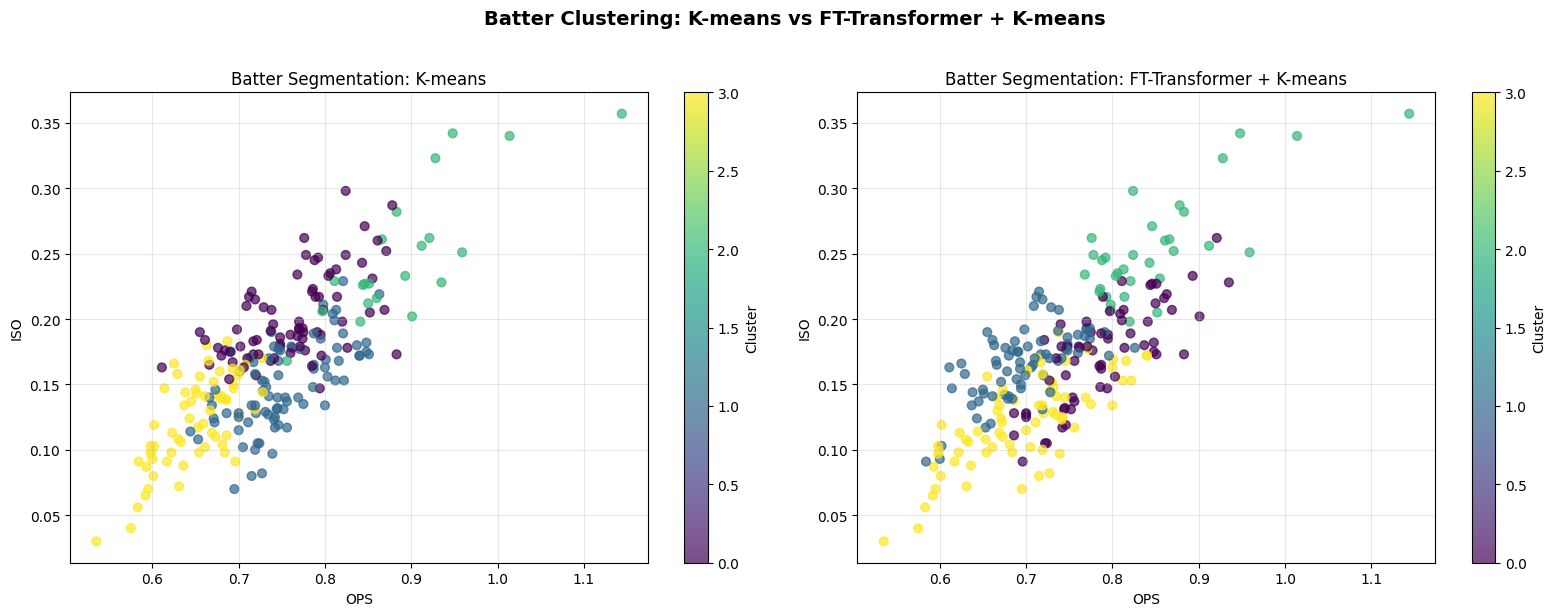

In [9]:
# Side-by-side scatter: OPS vs ISO
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in [
    (axes[0], 'km_cluster', 'K-means'),
    (axes[1], 'ft_cluster', 'FT-Transformer + K-means'),
]:
    scatter = ax.scatter(df_bat['ops'], df_bat['iso'], c=df_bat[col], cmap='viridis', s=40, alpha=0.7)
    ax.set_xlabel('OPS')
    ax.set_ylabel('ISO')
    ax.set_title(f'Batter Segmentation: {title}')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Batter Clustering: K-means vs FT-Transformer + K-means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Top players per cluster comparison
for method, col in [('K-means', 'km_cluster'), ('FT-Transformer + K-means', 'ft_cluster')]:
    print(f"\n{'='*60}")
    print(f"  {method}: Top 3 per cluster")
    print(f"{'='*60}")
    for cid in sorted(df_bat[col].unique()):
        top = df_bat[df_bat[col] == cid].nlargest(3, 'ops')
        print(f"\n  Cluster {cid} (n={len(df_bat[df_bat[col] == cid])})")
        print(top[['name', 'team', 'ops', 'iso', 'k_rate', 'bb_rate']].to_string(index=False))


  K-means: Top 3 per cluster

  Cluster 0 (n=76)
           name team   ops   iso    k_rate  bb_rate
Jonathan Aranda  TBR 0.883 0.173 25.355450 9.715640
   Byron Buxton  MIN 0.878 0.287 27.306273 7.564576
    Pete Alonso  NYM 0.871 0.252 22.849083 8.603667

  Cluster 1 (n=83)
           name team   ops   iso    k_rate   bb_rate
   Jose Ramirez  CLE 0.863 0.219 10.995542  9.806835
Geraldo Perdomo  ARI 0.851 0.173 11.527778 13.055556
     Yandy Diaz  TBR 0.848 0.182 14.132104  8.755760

  Cluster 2 (n=21)
           name team   ops   iso    k_rate   bb_rate
    Aaron Judge  NYY 1.144 0.357 23.564065 18.262150
  Shohei Ohtani  LAD 1.014 0.340 25.722146 14.993122
George Springer  TOR 0.959 0.251 18.941980 11.774744

  Cluster 3 (n=63)
            name team   ops   iso    k_rate  bb_rate
    Heliot Ramos  SFG 0.728 0.144 22.733813 7.482014
      Lenyn Sosa  CHW 0.727 0.170 23.345588 3.308824
Jasson Dominguez  NYY 0.719 0.131 26.806527 9.557110

  FT-Transformer + K-means: Top 3 per cluster

---
## 2. Pitcher Segmentation

In [11]:
query_pitchers = f"""
SELECT
    season, name, team, era, whip,
    avg AS batting_average_against,
    k_9, bb_9, hr_9, gbpct, fbpct, ip, gs
FROM `{PROJECT_ID}.{DATASET_ID}.fact_pitching_stats_master`
WHERE season = 2025 AND gs > 0 AND ip > 90
ORDER BY era ASC
"""

df_pit = client.query(query_pitchers).to_dataframe()
print(f"Eligible pitchers: {len(df_pit)}")

pit_features = ['era', 'k_9', 'gbpct']
X_pit = df_pit[pit_features]
X_pit.describe().round(3)

c:\Users\inthe\Desktop\Python_scripts_2025\diamond-lens\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Eligible pitchers: 118


,era,k_9,gbpct
count,118.000,118.000,118.000
mean,4.026,8.226,0.417
std,1.003,1.569,0.069
min,1.730,5.050,0.275
25%,3.335,7.050,0.372
50%,4.010,8.080,0.411
75%,4.640,9.335,0.456
max,6.700,11.890,0.653


### 2-A. K-means (Baseline)

In [12]:
scaler_pit = StandardScaler()
X_pit_scaled = scaler_pit.fit_transform(X_pit)

kmeans_pit = KMeans(n_clusters=4, random_state=42)
df_pit['km_cluster'] = kmeans_pit.fit_predict(X_pit_scaled)

pit_km_eval = evaluate_clustering(X_pit_scaled, df_pit['km_cluster'], "Pitcher K-means")
print(f"\nCluster distribution:\n{df_pit['km_cluster'].value_counts().sort_index()}")

--- Pitcher K-means ---
  Silhouette Score:        0.2474  (higher is better, range: -1 to 1)
  Calinski-Harabasz Index: 51.78  (higher is better)
  Davies-Bouldin Index:    1.2150  (lower is better)

Cluster distribution:
km_cluster
0    25
1    27
2    33
3    33
Name: count, dtype: int64


### 2-B. FT-Transformer + K-means

In [13]:
ft_model_pit, ft_scaler_pit, pit_embeddings = train_ft_transformer(
    X_pit, n_features=len(pit_features), epochs=200, embedding_dim=16
)
print(f"Embedding shape: {pit_embeddings.shape}")

INFO:backend.app.services.ft_transformer:  Epoch 50/200, Loss: 0.041323
INFO:backend.app.services.ft_transformer:  Epoch 100/200, Loss: 0.023021
INFO:backend.app.services.ft_transformer:  Epoch 150/200, Loss: 0.024406
INFO:backend.app.services.ft_transformer:  Epoch 200/200, Loss: 0.016816
INFO:backend.app.services.ft_transformer:FT-Transformer trained: 118 samples → 16d embeddings


Embedding shape: (118, 16)


In [14]:
kmeans_ft_pit = KMeans(n_clusters=4, random_state=42)
df_pit['ft_cluster'] = kmeans_ft_pit.fit_predict(pit_embeddings)

pit_ft_eval = evaluate_clustering(pit_embeddings, df_pit['ft_cluster'], "Pitcher FT-Transformer + K-means")
print(f"\nCluster distribution:\n{df_pit['ft_cluster'].value_counts().sort_index()}")

--- Pitcher FT-Transformer + K-means ---
  Silhouette Score:        0.2366  (higher is better, range: -1 to 1)
  Calinski-Harabasz Index: 46.00  (higher is better)
  Davies-Bouldin Index:    1.2677  (lower is better)

Cluster distribution:
ft_cluster
0    23
1    44
2    27
3    24
Name: count, dtype: int64


### 2-C. Pitcher Comparison

In [15]:
pit_comparison = pd.DataFrame([pit_km_eval, pit_ft_eval]).set_index('method')
print("=" * 60)
print("PITCHER SEGMENTATION: Metrics Comparison")
print("=" * 60)
print(pit_comparison.round(4))
print()

PITCHER SEGMENTATION: Metrics Comparison
                                  silhouette  calinski_harabasz  \
method                                                            
Pitcher K-means                       0.2474            51.7768   
Pitcher FT-Transformer + K-means      0.2366            45.9995   

                                  davies_bouldin  
method                                            
Pitcher K-means                           1.2150  
Pitcher FT-Transformer + K-means          1.2677  



In [16]:
print("K-means cluster means:")
print(df_pit.groupby('km_cluster')[pit_features].mean().round(3))
print("\nFT-Transformer + K-means cluster means:")
print(df_pit.groupby('ft_cluster')[pit_features].mean().round(3))

K-means cluster means:
              era    k_9  gbpct
km_cluster                     
0           3.218  8.227  0.513
1           5.394  7.525  0.400
2           3.489  9.967  0.384
3           4.054  7.058  0.392

FT-Transformer + K-means cluster means:
              era     k_9  gbpct
ft_cluster                      
0           3.160   8.187  0.518
1           4.496   6.856  0.381
2           3.382  10.156  0.382
3           4.716   8.604  0.426


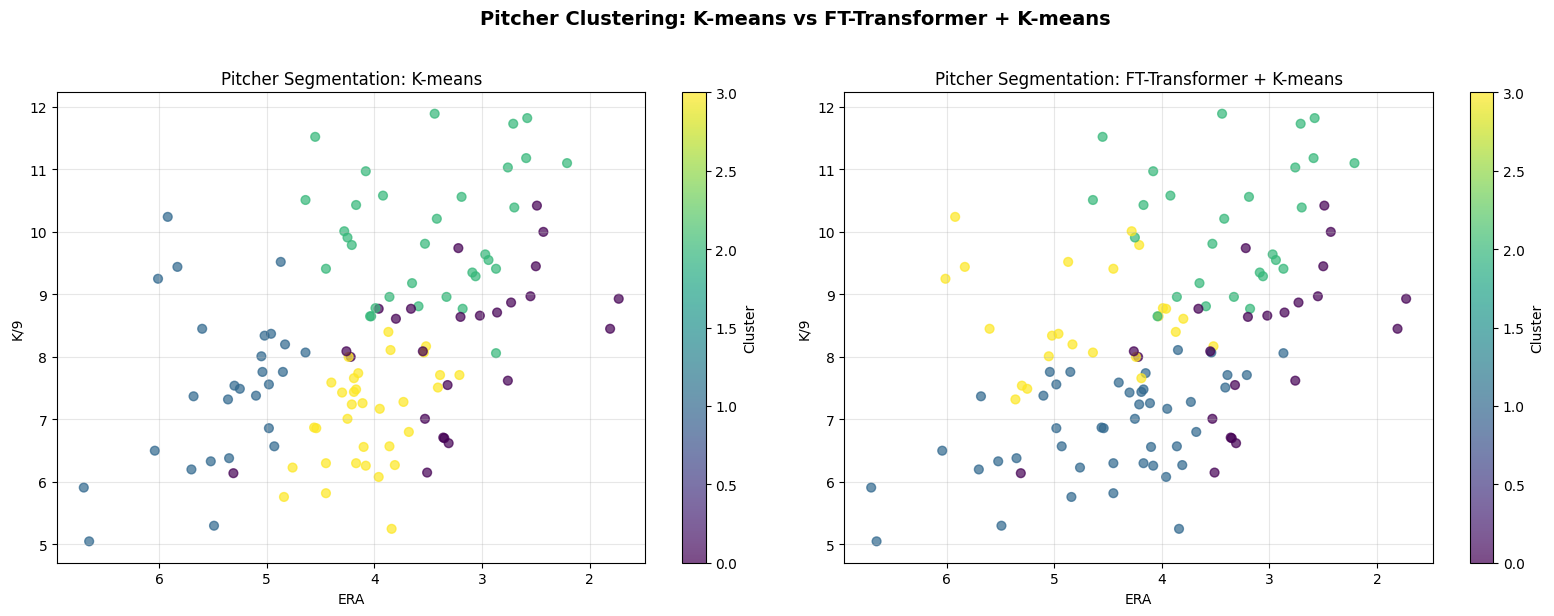

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in [
    (axes[0], 'km_cluster', 'K-means'),
    (axes[1], 'ft_cluster', 'FT-Transformer + K-means'),
]:
    scatter = ax.scatter(df_pit['era'], df_pit['k_9'], c=df_pit[col], cmap='viridis', s=40, alpha=0.7)
    ax.set_xlabel('ERA')
    ax.set_ylabel('K/9')
    ax.set_title(f'Pitcher Segmentation: {title}')
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Pitcher Clustering: K-means vs FT-Transformer + K-means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
for method, col in [('K-means', 'km_cluster'), ('FT-Transformer + K-means', 'ft_cluster')]:
    print(f"\n{'='*60}")
    print(f"  {method}: Top 3 per cluster (by ERA)")
    print(f"{'='*60}")
    for cid in sorted(df_pit[col].unique()):
        top = df_pit[df_pit[col] == cid].nsmallest(3, 'era')
        print(f"\n  Cluster {cid} (n={len(df_pit[df_pit[col] == cid])})")
        print(top[['name', 'team', 'era', 'k_9', 'gbpct', 'whip', 'ip']].to_string(index=False))


  K-means: Top 3 per cluster (by ERA)

  Cluster 0 (n=25)
          name team  era   k_9  gbpct  whip    ip
Nathan Eovaldi  TEX 1.73  8.93  0.503  0.85 130.0
 Trevor Rogers  BAL 1.81  8.45  0.460  0.90 109.2
  Hunter Brown  HOU 2.43 10.00  0.481  1.03 185.1

  Cluster 1 (n=27)
            name   team  era  k_9  gbpct  whip    ip
Michael Lorenzen    KCR 4.64 8.07  0.393  1.33 141.2
      Zac Gallen    ARI 4.83 8.20  0.436  1.26 192.0
    Aaron Civale TRADED 4.85 7.76  0.340  1.26 102.0

  Cluster 2 (n=33)
           name team  era   k_9  gbpct  whip    ip
   Tarik Skubal  DET 2.21 11.10  0.410  0.89 195.1
     Chris Sale  ATL 2.58 11.82  0.390  1.07 125.2
Garrett Crochet  BOS 2.59 11.18  0.483  1.03 205.1

  Cluster 3 (n=33)
         name team  era  k_9  gbpct  whip    ip
 Matthew Boyd  CHC 3.21 7.71  0.379  1.09 179.2
  Ryne Nelson  ARI 3.39 7.71  0.399  1.07 154.0
Lucas Giolito  BOS 3.41 7.51  0.378  1.29 145.0

  FT-Transformer + K-means: Top 3 per cluster (by ERA)

  Cluster 0 (n=2

---
## 3. Overall Summary

In [19]:
# Combined comparison
all_results = pd.DataFrame([
    bat_km_eval, bat_ft_eval, pit_km_eval, pit_ft_eval
]).set_index('method')

print("=" * 70)
print("  OVERALL COMPARISON: K-means vs FT-Transformer + K-means")
print("=" * 70)
print(all_results.round(4))
print()
print("Interpretation:")
print("  Silhouette Score:        higher = better cluster separation (-1 to 1)")
print("  Calinski-Harabasz Index: higher = better cluster definition")
print("  Davies-Bouldin Index:    lower  = better cluster separation")

  OVERALL COMPARISON: K-means vs FT-Transformer + K-means
                                  silhouette  calinski_harabasz  \
method                                                            
Batter K-means                        0.2274            85.3460   
Batter FT-Transformer + K-means       0.2176            72.0935   
Pitcher K-means                       0.2474            51.7768   
Pitcher FT-Transformer + K-means      0.2366            45.9995   

                                  davies_bouldin  
method                                            
Batter K-means                            1.2632  
Batter FT-Transformer + K-means           1.2905  
Pitcher K-means                           1.2150  
Pitcher FT-Transformer + K-means          1.2677  

Interpretation:
  Silhouette Score:        higher = better cluster separation (-1 to 1)
  Calinski-Harabasz Index: higher = better cluster definition
  Davies-Bouldin Index:    lower  = better cluster separation


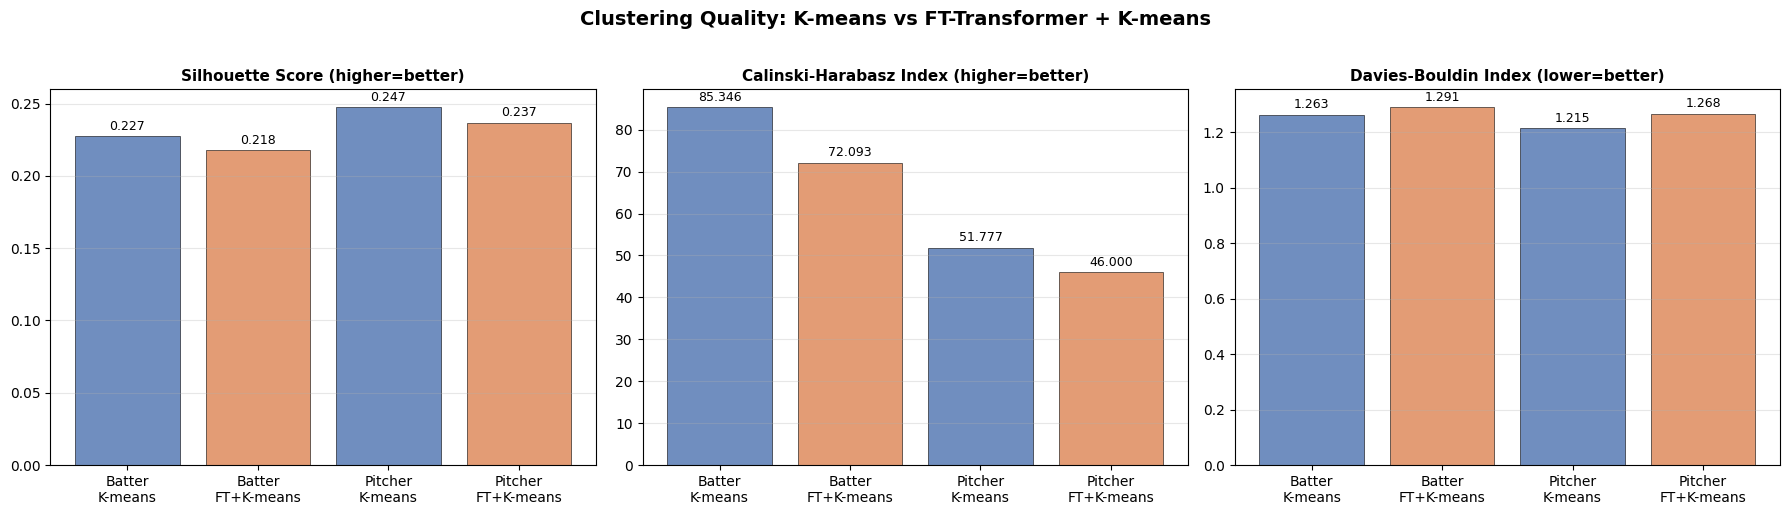

In [20]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('silhouette', 'Silhouette Score (higher=better)'),
    ('calinski_harabasz', 'Calinski-Harabasz Index (higher=better)'),
    ('davies_bouldin', 'Davies-Bouldin Index (lower=better)'),
]

labels = ['Batter\nK-means', 'Batter\nFT+K-means', 'Pitcher\nK-means', 'Pitcher\nFT+K-means']
colors = ['#4C72B0', '#DD8452', '#4C72B0', '#DD8452']

for ax, (metric, title) in zip(axes, metrics):
    values = all_results[metric].values
    bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(values),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Clustering Quality: K-means vs FT-Transformer + K-means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Agreement analysis: how many players are in the same cluster?
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

bat_ari = adjusted_rand_score(df_bat['km_cluster'], df_bat['ft_cluster'])
bat_nmi = normalized_mutual_info_score(df_bat['km_cluster'], df_bat['ft_cluster'])
pit_ari = adjusted_rand_score(df_pit['km_cluster'], df_pit['ft_cluster'])
pit_nmi = normalized_mutual_info_score(df_pit['km_cluster'], df_pit['ft_cluster'])

print("=" * 60)
print("  Cluster Assignment Agreement")
print("=" * 60)
print(f"  Batter - Adjusted Rand Index:          {bat_ari:.4f}")
print(f"  Batter - Normalized Mutual Information: {bat_nmi:.4f}")
print(f"  Pitcher - Adjusted Rand Index:          {pit_ari:.4f}")
print(f"  Pitcher - Normalized Mutual Information: {pit_nmi:.4f}")
print()
print("  ARI: 1.0 = identical, 0.0 = random")
print("  NMI: 1.0 = identical, 0.0 = independent")

  Cluster Assignment Agreement
  Batter - Adjusted Rand Index:          0.2349
  Batter - Normalized Mutual Information: 0.3405
  Pitcher - Adjusted Rand Index:          0.5661
  Pitcher - Normalized Mutual Information: 0.6393

  ARI: 1.0 = identical, 0.0 = random
  NMI: 1.0 = identical, 0.0 = independent


---
## 4. Vertex AI Model Registry への登録

学習済みモデルを Vertex AI Model Registry に登録し、本番環境での推論に利用できるようにします。

In [ ]:
from google.cloud import aiplatform
import joblib
import tempfile
import shutil
from pathlib import Path

# Vertex AI の初期化
aiplatform.init(project=PROJECT_ID, location='asia-northeast1')

print(f"Vertex AI initialized: project={PROJECT_ID}, location=asia-  gfvd     erwjhfjewifddd")

In [ ]:
def save_and_register_model(model, scaler, kmeans, model_type, features, season, metrics):
    """
    学習済みモデルを一時ディレクトリに保存し、Vertex AI Model Registry に登録する
    
    Args:
        model: 学習済みFT-Transformerモデル
        scaler: StandardScalerオブジェクト
        kmeans: KMeansオブジェクト
        model_type: "batter" or "pitcher"
        features: 使用した特徴量のリスト
        season: 学習に使用したシーズン
        metrics: 評価指標（dict）
    """
    # 一時ディレクトリを作成
    with tempfile.TemporaryDirectory() as temp_dir:
        model_dir = Path(temp_dir)
        
        # モデルを保存
        torch.save(model.state_dict(), model_dir / 'ft_transformer.pth')
        joblib.dump(scaler, model_dir / 'scaler.joblib')
        joblib.dump(kmeans, model_dir / 'kmeans.joblib')
        
        # メタデータを保存
        metadata = {
            'model_type': model_type,
            'algorithm': 'FT-Transformer + K-means',
            'features': features,
            'n_clusters': kmeans.n_clusters,
            'embedding_dim': model.embedding_dim,
            'season': season,
            'metrics': metrics
        }
        
        with open(model_dir / 'metadata.json', 'w') as f:
            import json
            json.dump(metadata, f, indent=2)
        
        print(f"Models saved to temporary directory: {model_dir}")
        print(f"Files: {list(model_dir.glob('*'))}")
        
        # Vertex AI Model Registry に登録
        display_name = f"player-segmentation-{model_type}-ft-transformer"
        
        try:
            model_resource = aiplatform.Model.upload(
                display_name=display_name,
                artifact_uri=str(model_dir),
                serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/pytorch-cpu.1-13:latest",
                description=f"FT-Transformer + K-means for {model_type} segmentation (Season {season})",
                labels={
                    "model_type": model_type,
                    "algorithm": "ft-transformer",
                    "season": str(season)
                }
            )
            
            print(f"\n✅ Model registered successfully!")
            print(f"   Model ID: {model_resource.name}")
            print(f"   Display Name: {display_name}")
            print(f"   Resource Name: {model_resource.resource_name}")
            
            return model_resource
            
        except Exception as e:
            print(f"\n❌ Error registering model: {e}")
            print(f"   Tip: Ensure you have 'Vertex AI User' role in GCP project")
            return None

### 4-A. Batter モデルの登録

In [ ]:
# Batter モデルを登録
batter_model_resource = save_and_register_model(
    model=ft_model_bat,
    scaler=ft_scaler_bat,
    kmeans=kmeans_ft_bat,
    model_type='batter',
    features=bat_features,
    season=2025,
    metrics=bat_ft_eval
)

### 4-B. Pitcher モデルの登録

In [ ]:
# Pitcher モデルを登録
pitcher_model_resource = save_and_register_model(
    model=ft_model_pit,
    scaler=ft_scaler_pit,
    kmeans=kmeans_ft_pit,
    model_type='pitcher',
    features=pit_features,
    season=2025,
    metrics=pit_ft_eval
)

### 4-C. 登録済みモデルの確認

In [ ]:
# 登録済みモデルのリストを表示
models = aiplatform.Model.list(
    filter='labels.algorithm="ft-transformer"',
    order_by='create_time desc'
)

print("=" * 70)
print("  Registered Models in Vertex AI Model Registry")
print("=" * 70)

for model in models[:10]:  # 最新10件を表示
    print(f"\nDisplay Name: {model.display_name}")
    print(f"  Resource Name: {model.resource_name}")
    print(f"  Labels: {model.labels}")
    print(f"  Created: {model.create_time}")